### Data Loading

In [ ]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.simplefilter(action='ignore')

from src.costream.data import group_files_by_subject
from src.costream.evaluation import run_experiment, run_subject_cv
import numpy as np
from src.fall_lm import FallLM
from src.models import get_model_specs
from src import utils

FALL_DIR = "data/farseeing/fall"
FREQ = 100
WINDOW_SEC = 3

In [2]:
# Data loading based on metadata
import pandas as pd 

data_desc = pd.read_excel("data/farseeing/description.xlsx", engine='openpyxl',
                          usecols=['Randomnumber', 'Sensor_location', 'Sample_rate_Hz'])
l5 = data_desc[data_desc['Sensor_location'] == 'L5']
l5 = l5[l5['Sample_rate_Hz'] == FREQ]
l5_subjects = set(l5['Randomnumber'].str.split('-').str[0])
l5[l5['Sample_rate_Hz'] != FREQ]
len(l5_subjects)

54

In [27]:
# Subject-wise train/test split
from sklearn.model_selection import train_test_split

# Group files
fall_subject_map = group_files_by_subject(FALL_DIR, id_extractor=utils.fall_id_extractor)
# Limit fall subjects to subjects with 'L5' data only
fall_subject_map = {s: fps for s, fps in fall_subject_map.items() if s in l5_subjects}
fall_subjects = list(fall_subject_map.keys())
print(f"Found {len(fall_subjects)} fall subjects: {fall_subjects[:3]} ...")

# Split Subjects into Train / Test
train_subjs_fall, test_subjs_fall = train_test_split(fall_subjects, test_size=0.2, random_state=42)
# For each subject 's', get every file 'f' in fall_subject_map[s]
train_files_fall = [f for s in train_subjs_fall for f in fall_subject_map[s]]
test_files_fall  = [f for s in test_subjs_fall  for f in fall_subject_map[s]]
# Now load them
train_dfs_fall = utils.load_fall_subject(train_files_fall)
test_dfs_fall  = utils.load_fall_subject(test_files_fall)

Found 40 fall subjects: ['93807530', '79336438', '18194920'] ...


### Cross-validation Experiment

In [4]:
# Load the subject data into memory for quick access during modeling
# This is a dict of {subject_id: [list of dataframes for that subject's files]}
subject_df_map = {s: utils.load_fall_subject(fall_subject_map[s]) for s in fall_subject_map.keys()}

In [ ]:
# Run five-fold cross-validation
import warnings, os
warnings.filterwarnings("ignore")
os.makedirs('output/results', exist_ok=True)

model_specs = get_model_specs(random_state=42)

cv_results_df = []
print("Running cross-validation experiments...")
cv_res = run_subject_cv(
    subject_map=subject_df_map,
    model_specs=model_specs,
    feature_cols=['mag'],
    window_size=WINDOW_SEC,
    cv=5,
    step=1.0,
    spacing="multiphase",
    verbose=True,
    use_post_event_data=False, 
    tolerance=[3,20]
)
display(cv_res)
cv_res.to_csv('output/results/cv_results.csv', index=False)

Running cross-validation experiments...

=== Fold 1/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (1627, 300)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
Epoch 22: Train 0.0186 | Val 0.0970:  23%|██▎       | 23/100 [00:32<01:49,  1.42s/it]


  Fold Results (Mean F1):
model
FallLM        0.574713
Mantis        0.819277
MiniRocket    0.756757
MrSQM         0.675325
Quant         0.788732
WEASEL        0.783784
Name: f1-score, dtype: float64

=== Fold 2/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (2563, 300)


Epoch 39: Train 0.0092 | Val 0.0090:  40%|████      | 40/100 [01:24<02:07,  2.12s/it]


  Fold Results (Mean F1):
model
FallLM        0.767123
Mantis        0.831169
MiniRocket    0.816901
MrSQM         0.716049
Quant         0.853333
WEASEL        0.805556
Name: f1-score, dtype: float64

=== Fold 3/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (2380, 300)


...

Epoch 22: Train 0.0024 | Val 0.0342:  23%|██▎       | 23/100 [00:50<02:47,  2.18s/it]


  Fold Results (Mean F1):
model
FallLM        0.658228
Mantis        0.782609
MiniRocket    0.787879
MrSQM         0.600000
Quant         0.771429
WEASEL        0.818182
Name: f1-score, dtype: float64

=== Fold 5/5 | Train Subjects: 32 | Test Subjects: 8 ===
  Segmented Train Data: (2755, 300)


Epoch 20: Train 0.0028 | Val 0.0416:  21%|██        | 21/100 [00:48<03:02,  2.31s/it]


  Fold Results (Mean F1):
model
FallLM        0.745098
Mantis        0.844444
MiniRocket    0.857143
MrSQM         0.666667
Quant         0.837209
WEASEL        0.818182
Name: f1-score, dtype: float64


,model,tp,fp,tn,fn,runtime,delay,precision,recall,specificity,f1-score,auc,false alarm rate,miss rate,gain,thresh,fold
0,WEASEL,29,9,36586,7,8.032176,-1.524062,0.763158,0.805556,0.999754,0.783784,0.902655,0.088216,0.068612,-0.225441,0.500000,1
1,MrSQM,26,15,36580,10,7.110480,-0.296406,0.634146,0.722222,0.999590,0.675325,0.860906,0.147026,0.098018,-0.343062,0.500000,1
2,Quant,28,7,36588,8,0.320210,-1.117812,0.800000,0.777778,0.999809,0.788732,0.888793,0.068612,0.078414,-0.225441,0.500000,1
3,MiniRocket,28,10,36585,8,0.545152,-1.298594,0.736842,0.777778,0.999727,0.756757,0.888752,0.098018,0.078414,-0.254846,0.500000,1
4,Mantis,34,13,36582,2,1.317206,-1.704844,0.723404,0.944444,0.999645,0.819277,0.972045,0.127423,0.019604,-0.166630,0.500000,1
5,FallLM,25,26,36569,11,0.012238,-1.524062,0.490196,0.694444,0.999290,0.574713,0.846867,0.254846,0.107819,-0.470485,0.888889,1
6,WEASEL,29,3,42029,11,2.891204,-0.866944,0.906250,0.725000,0.999929,0.805556,0.862464,0.025603,0.093877,-0.213357,0.500000,2
7,MrSQM,29,12,42020,11,2.323576,-0.905000,0.707317,0.725000,0.999715,0.716049,0.862357,0.102411,0.093877,-0.290165,0.500000,2
8,Quant,32,3,42029,8,0.209920,-0.894722,0.914286,0.800000,0.999929,0.853333,0.899964,0.025603,0.068274,-0.162151,0.500000,2
9,MiniRocket,29,2,42030,11,0.187168,-0.755833,0.935484,0.725000,0.999952,0.816901,0.862476,0.017069,0.093877,-0.204823,0.500000,2


In [6]:
# Aggregate CV results by model and display sorted by F1-score
from src.costream.evaluation import aggregate_cv_results

cv_res = pd.read_csv('output/results/cv_results.csv')
agg_res = aggregate_cv_results(cv_res, exclude_cols=['tp', 'fp', 'tn', 'fn',
                                                      'thresh', 'gain', 'specificity'])
agg_res.to_csv('output/results/cv_results_agg.csv', index=False)
display(agg_res.sort_values('f1-score', ascending=False))

,model,runtime,delay,precision,recall,f1-score,auc,false alarm rate,miss rate
4,Quant,0.26 ± 0.05,-0.92 ± 0.11,0.83 ± 0.07,0.81 ± 0.03,0.82 ± 0.03,0.91 ± 0.01,0.06 ± 0.03,0.06 ± 0.01
1,Mantis,0.89 ± 0.28,-1.16 ± 0.33,0.78 ± 0.05,0.88 ± 0.06,0.82 ± 0.02,0.94 ± 0.03,0.08 ± 0.03,0.04 ± 0.02
2,MiniRocket,0.28 ± 0.18,-1.0 ± 0.19,0.84 ± 0.08,0.79 ± 0.05,0.81 ± 0.04,0.89 ± 0.02,0.05 ± 0.03,0.07 ± 0.02
5,WEASEL,4.4 ± 2.48,-1.12 ± 0.25,0.82 ± 0.06,0.81 ± 0.05,0.81 ± 0.02,0.9 ± 0.03,0.06 ± 0.02,0.06 ± 0.02
0,FallLM,0.01 ± 0.0,-1.35 ± 0.32,0.63 ± 0.13,0.75 ± 0.09,0.68 ± 0.08,0.88 ± 0.05,0.15 ± 0.08,0.08 ± 0.03
3,MrSQM,3.69 ± 2.32,-0.59 ± 0.29,0.63 ± 0.08,0.72 ± 0.01,0.67 ± 0.05,0.86 ± 0.0,0.14 ± 0.05,0.09 ± 0.01


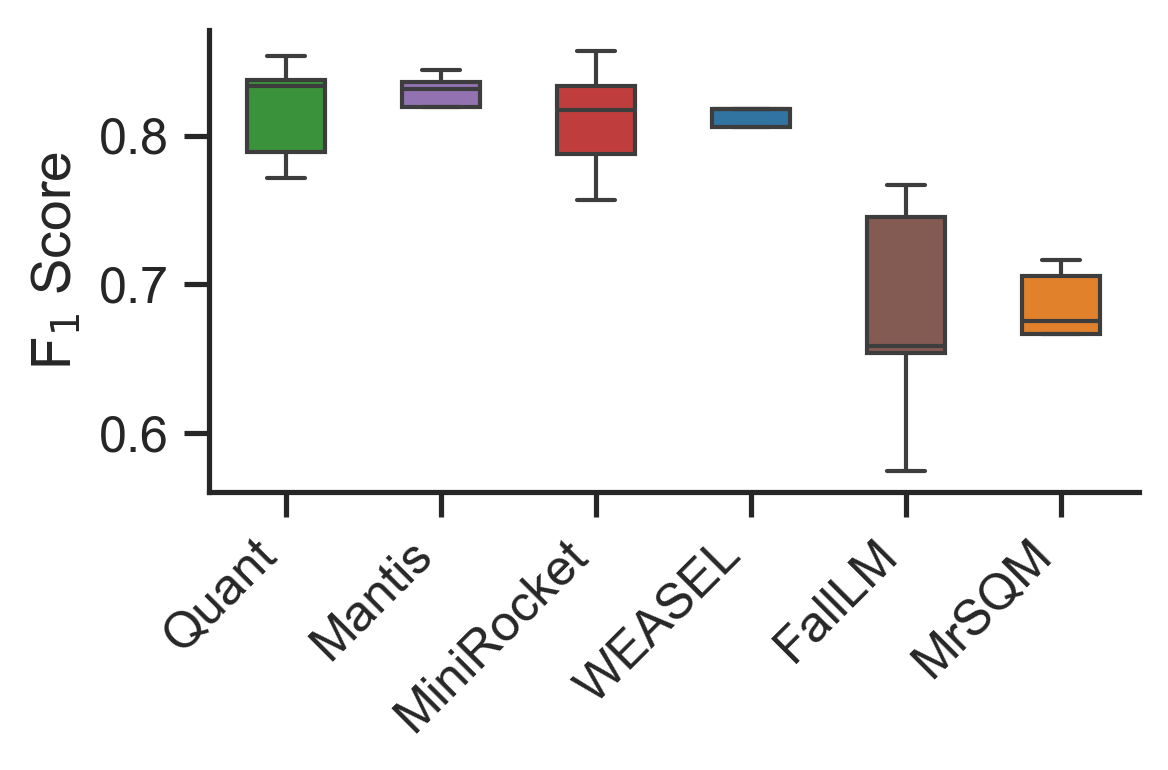

In [7]:
from costream.evaluation import metric_box
import matplotlib.pyplot as plt

os.makedirs("output/figures", exist_ok=True)
model_order_by_f1 = agg_res.sort_values('f1-score', ascending=False)['model'].tolist()
fig, ax = plt.subplots(1,1, figsize=(4,2), dpi=300)
metric_box(cv_res, metric='f1-score', x='model', order=model_order_by_f1, ax=ax)
ax.set_title("")
ax.set_ylabel(r"F$_1$ Score")
# save figure
fig.savefig("output/figures/f1_score_boxplot.pdf", dpi=300, bbox_inches='tight')

### Fall Scarcity Experiment

In [9]:
# Segment and save
win_sec = 3
os.makedirs("data/preprocessed", exist_ok=True)
    
# 2D magnitude signal
X_train, y_train, test_signals, test_events = utils.segment_and_save(
    train_dfs_fall,
    test_dfs_fall,
    feat_cols=["mag"], 
    win_sec=win_sec, 
    thresh=1.4, 
    suffix=""
)

WIN_SEC=3:
  Train: X=(1924, 300), y=(1924,), balance=[1812  112] (0=ADL, 1=Fall)
  Test:  34 signals, 34 event lists


In [10]:
# Fractions of FALL EVENTS to keep
fractions = [0.01, 0.05, 0.10, 0.25, 0.50, 1.0]

# Multiple seeds for robustness
seeds = [0, 1, 2, 3, 4]

# Identify fall and ADL indices ONCE
fall_indices = np.where(y_train == 1)[0]
adl_indices  = np.where(y_train == 0)[0]

all_results = []

for frac in fractions:
    for seed in seeds:
        rng = np.random.default_rng(seed)
        if frac < 1.0:
            n_keep = max(1, int(np.ceil(frac * len(fall_indices))))
            selected_falls = rng.choice(fall_indices, size=n_keep, replace=False)
            keep_indices = np.concatenate([selected_falls, adl_indices])
        else:
            n_keep = len(fall_indices)
            keep_indices = np.arange(len(y_train))
        # Shuffle to avoid any ordering bias in training data
        rng.shuffle(keep_indices)
        # Subset training data
        X_sub = X_train[keep_indices]
        y_sub = y_train[keep_indices]
        # Define models exactly as before
        scarc_specs = get_model_specs(random_state=seed)
        # Run experiment
        res = run_experiment(
            X_train=X_sub,
            y_train=y_sub,
            test_signals=test_signals,
            test_event_points=test_events,
            model_specs=scarc_specs,
            window_size=3.0,
            step=1.0,
            freq=100,
            signal_thresh=1.4,
            tolerance=[3,20],
            debounce_secs=60,
            verbose=False
        )

        res['train_fraction'] = frac
        res['seed'] = seed
        res['n_falls_used'] = n_keep
        res['total_samples_used'] = len(keep_indices)
        all_results.append(res)
# Combine all results
final_scarcity_df = pd.concat(all_results, ignore_index=True)
print("\nFINAL DATA SCARCITY RESULTS (Multi-Seed)")
display(final_scarcity_df)

Epoch 16: Train 0.0057 | Val 0.0015:  17%|█▋        | 17/100 [00:26<02:09,  1.56s/it]
Epoch 16: Train 0.0027 | Val 0.0005:  17%|█▋        | 17/100 [00:26<02:08,  1.55s/it]
Epoch 16: Train 0.0067 | Val 0.0009:  17%|█▋        | 17/100 [00:26<02:09,  1.56s/it]
Epoch 17: Train 0.0076 | Val 0.0011:  18%|█▊        | 18/100 [00:27<02:06,  1.55s/it]
Epoch 16: Train 0.0044 | Val 0.0017:  17%|█▋        | 17/100 [00:26<02:09,  1.56s/it]
Epoch 28: Train 0.0005 | Val 0.0171:  29%|██▉       | 29/100 [00:43<01:45,  1.48s/it]
Epoch 35: Train 0.0002 | Val 0.0024:  36%|███▌      | 36/100 [00:52<01:32,  1.45s/it]
Epoch 26: Train 0.0005 | Val 0.0151:  27%|██▋       | 27/100 [00:39<01:46,  1.47s/it]
Epoch 29: Train 0.0009 | Val 0.0127:  30%|███       | 30/100 [00:44<01:42,  1.47s/it]
Epoch 32: Train 0.0002 | Val 0.0096:  33%|███▎      | 33/100 [00:48<01:37,  1.46s/it]
Epoch 38: Train 0.0003 | Val 0.0088:  39%|███▉      | 39/100 [00:57<01:29,  1.47s/it]
Epoch 26: Train 0.0004 | Val 0.0105:  27%|██▋       | 


FINAL DATA SCARCITY RESULTS (Multi-Seed)


,model,tp,fp,tn,fn,runtime,delay,precision,recall,specificity,f1-score,auc,false alarm rate,miss rate,gain,thresh,train_fraction,seed,n_falls_used,total_samples_used
0,WEASEL,0,0,40187,38,5.952295,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000,0.339217,-0.678435,0.500000,0.01,0,2,1814
1,MrSQM,0,0,40187,38,4.837823,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000,0.339217,-0.678435,0.500000,0.01,0,2,1814
2,Quant,2,0,40187,36,0.252697,-0.058824,1.000000,0.052632,1.000000,0.100000,0.526316,0.000000,0.321364,-0.642728,0.500000,0.01,0,2,1814
3,MiniRocket,8,2,40185,30,0.347884,-0.382353,0.800000,0.210526,0.999950,0.333333,0.605238,0.017854,0.267803,-0.553460,0.500000,0.01,0,2,1814
4,Mantis,0,0,40187,38,0.514987,0.000000,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000,0.339217,-0.678435,0.500000,0.01,0,2,1814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,MrSQM,31,10,40177,7,4.350165,-0.073088,0.756098,0.815789,0.999751,0.784810,0.907770,0.089268,0.062487,-0.214243,0.500000,1.00,4,112,1924
176,Quant,33,8,40179,5,0.247740,-1.228529,0.804878,0.868421,0.999801,0.835443,0.934111,0.071414,0.044634,-0.160682,0.500000,1.00,4,112,1924
177,MiniRocket,34,6,40181,4,0.342100,-1.398676,0.850000,0.894737,0.999851,0.871795,0.947294,0.053561,0.035707,-0.124975,0.500000,1.00,4,112,1924
178,Mantis,34,6,40181,4,0.449633,-1.722206,0.850000,0.894737,0.999851,0.871795,0.947294,0.053561,0.035707,-0.124975,0.500000,1.00,4,112,1924


In [11]:
# Compute fall ratio percentage
final_scarcity_df['fall_ratio_pct'] = (final_scarcity_df['n_falls_used'] / final_scarcity_df['total_samples_used']) * 100
summary_df = (
    final_scarcity_df
    .groupby(['model', 'train_fraction', 'fall_ratio_pct', 'total_samples_used'])
    .agg({
        'f1-score': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'precision': ['mean', 'std'],
        'auc': ['mean', 'std'],
        'false alarm rate': ['mean', 'std']
    })
    .reset_index()
)
display(summary_df.sort_values(by=['train_fraction', 'model']))

model train_fraction fall_ratio_pct total_samples_used  f1-score  \
                                                                     mean   
0       FallLM           0.01       0.110254               1814  0.123464   
6       Mantis           0.01       0.110254               1814  0.000000   
12  MiniRocket           0.01       0.110254               1814  0.152381   
18       MrSQM           0.01       0.110254               1814  0.000000   
24       Quant           0.01       0.110254               1814  0.030256   
30      WEASEL           0.01       0.110254               1814  0.000000   
1       FallLM           0.05       0.330033               1818  0.000000   
7       Mantis           0.05       0.330033               1818  0.428087   
13  MiniRocket           0.05       0.330033               1818  0.567797   
19       MrSQM           0.05       0.330033               1818  0.000000   
25       Quant           0.05       0.330033               1818  0.459821   
31      WEASEL           0.05       0.330033               1818  0.076190   
2       FallLM           0.10       0.657895               1824  0.396134   
8       Mantis           0.10       0.657895               1824  0.686835   
14  MiniRocket           0.10       0.657895               1824  0.665459   
20       MrSQM           0.10       0.657895               1824  0.000000   
26       Quant           0.10       0.657895               1824  0.655354   
32      WEASEL           0.10       0.657895               1824  0.524240   
3       FallLM           0.25       1.521739               1840  0.668053   
9       Mantis           0.25       1.521739               1840  0.816573   
15  MiniRocket           0.25       1.521739               1840  0.787867   
21       MrSQM           0.25       1.521739               1840  0.473152   
27       Quant           0.25       1.521739               1840  0.827391   
33      WEASEL           0.25       1.521739               1840  0.827310   
4       FallLM           0.50       2.997859               1868  0.714537   
10      Mantis           0.50       2.997859               1868  0.836413   
16  MiniRocket           0.50       2.997859               1868  0.865493   
22       MrSQM           0.50       2.997859               1868  0.689058   
28       Quant           0.50       2.997859               1868  0.855673   
34      WEASEL           0.50       2.997859               1868  0.876396   
5       FallLM           1.00       5.821206               1924  0.713291   
11      Mantis           1.00       5.821206               1924  0.848673   
17  MiniRocket           1.00       5.821206               1924  0.876324   
23       MrSQM           1.00       5.821206               1924  0.775759   
29       Quant           1.00       5.821206               1924  0.844067   
35      WEASEL           1.00       5.821206               1924  0.887765   

                recall           precision                 auc            \
         std      mean       std      mean       std      mean       std   
0   0.248401  0.084211  0.173963  0.400000  0.547723  0.542105  0.086982   
6   0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  0.000000   
12  0.169700  0.094737  0.107863  0.420000  0.402492  0.547351  0.053923   
18  0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  0.000000   
24  0.044868  0.015789  0.023538  0.400000  0.547723  0.507895  0.011769   
30  0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  0.000000   
1   0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  0.000000   
7   0.114072  0.284211  0.091917  0.948039  0.078401  0.642095  0.045950   
13  0.082542  0.421053  0.081111  0.885739  0.023195  0.710501  0.040555   
19  0.000000  0.000000  0.000000  0.000000  0.000000  0.500000  0.000000   
25  0.176365  0.310526  0.130787  1.000000  0.000000  0.655263  0.065394   
31  0.104328  0.042105  0.057655  0.400000  0.547723  0.521053  0.028828   
2   0.366190  0.38

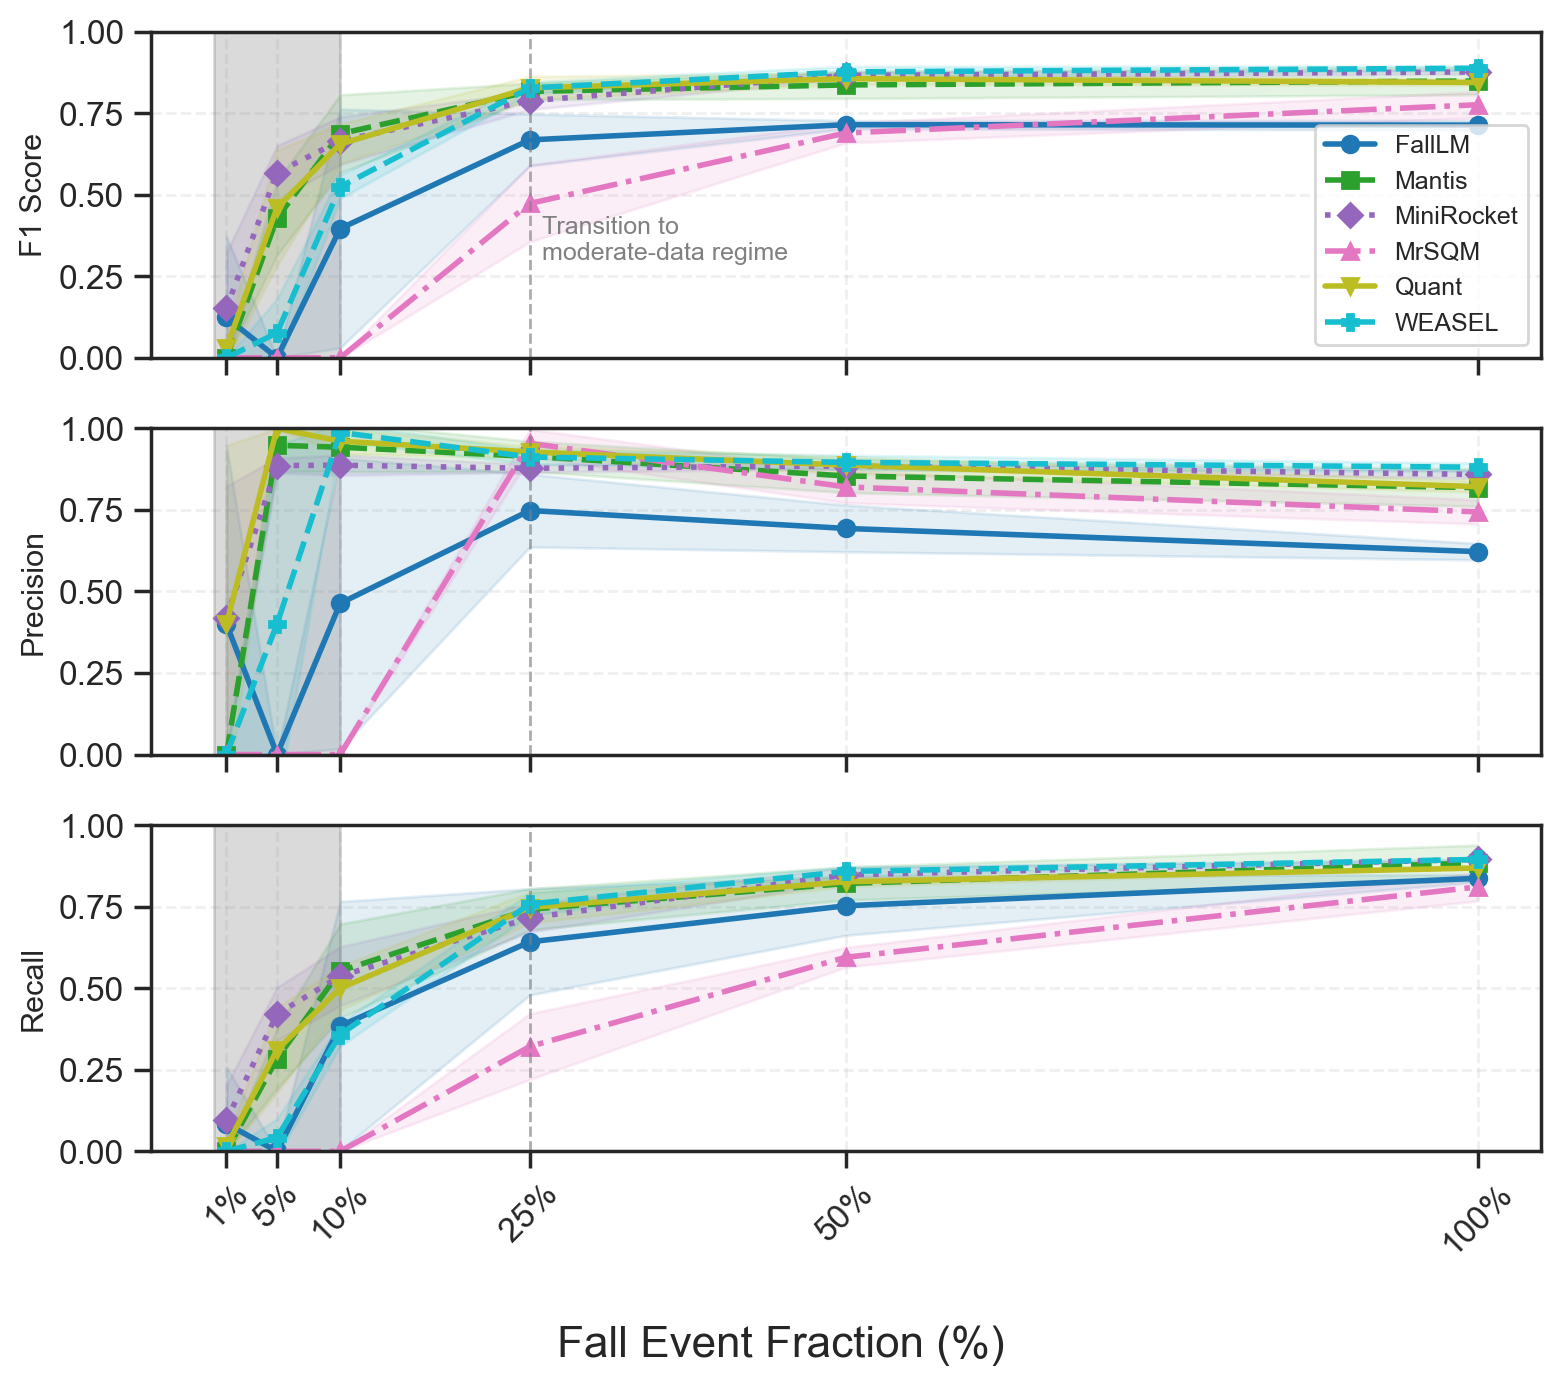

In [12]:
from matplotlib import markers
import matplotlib.pyplot as plt
import numpy as np

summary_df['fall_event_fraction_pct'] = summary_df['train_fraction'] * 100
models = summary_df["model"].unique()
metrics = ['f1-score', 'precision', 'recall']

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
linestyles = ['-', '--', ':', '-.']
markers = ['o', 's', 'D', '^', 'v', 'P', '*']
fig, axes = plt.subplots(3, 1, figsize=(8, 7), dpi=200, sharex=True)
summary_df_sorted = summary_df.sort_values(['model', 'fall_event_fraction_pct'])

for ax, metric in zip(axes, metrics):
    for idx, model in enumerate(models):
        sub = summary_df_sorted[summary_df_sorted["model"] == model]
        x = sub["fall_event_fraction_pct"].values
        y = sub[metric]["mean"].values
        yerr = sub[metric]["std"].values

        # Highlight extreme scarcity region
        ax.axvspan(0, 10, color='gray', alpha=0.05)
        ax.plot(
            x, y,
            marker=markers[idx % len(markers)],
            linewidth=2,
            label=model,
            color=colors[idx],
            linestyle=linestyles[idx % len(linestyles)],
            markersize=6
        )
        ax.fill_between(x, y - yerr, y + yerr, alpha=0.12, color=colors[idx])
    # Mark regime transition where models converge
    transition_point = 25
    ax.axvline(transition_point, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_ylabel(metric.replace('-', ' ').title(), fontsize=11)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linestyle='--')

    if metric == 'f1-score':
        ax.legend(fontsize=9, loc='best')
        ax.text(
            26, 0.3,
            "Transition to\nmoderate-data regime",
            fontsize=9,
            color='gray'
        )

    ax.set_xticks(sorted(summary_df_sorted["fall_event_fraction_pct"].unique()))
    ax.set_xticklabels(
        [f"{x:.0f}%" for x in sorted(summary_df_sorted["fall_event_fraction_pct"].unique())],
        rotation=45
    )

fig.supxlabel('Fall Event Fraction (%)')
plt.tight_layout()
plt.savefig('output/figures/scarcity_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Cross-dataset generalisation experiments
Train on `FallAllD` (simulated) and test on `FARSEEING` (real-world)

In [13]:
from src.fallalld import load_fallalld, adapter_fallalld_to_costream

fallalld_df = load_fallalld()
fallalld_subject_map = adapter_fallalld_to_costream(fallalld_df)

# Create training data from FallALlD
fallalld_subjects = list(fallalld_subject_map.keys())
fallalld_train_subjects, fallalld_test_subjects = train_test_split(
    fallalld_subjects, test_size=0.2, random_state=42)
fallalld_train_map = {s: fallalld_subject_map[s] for s in fallalld_train_subjects}

Adapting DataFrame to Costream format...


100%|██████████| 1745/1745 [00:00<00:00, 8579.74it/s]


In [14]:
fallalld_train_dfs = []
for s in fallalld_train_subjects:
    fallalld_train_dfs.extend(fallalld_subject_map[s])
fall_alld_test_dfs = []
for s in fallalld_test_subjects:
    fall_alld_test_dfs.extend(fallalld_subject_map[s])

In [15]:
X_train_f, y_train_f, test_signals_f, test_events_f = utils.segment_and_save(
    fallalld_train_dfs, fall_alld_test_dfs,
    feat_cols=['mag'], win_sec=3, thresh=1.4, suffix="fallalld", freq=100, orig_freq=238)

Resampling from 238Hz to 100Hz...
WIN_SEC=3:
  Train: X=(5597, 300), y=(5597,), balance=[5242  355] (0=ADL, 1=Fall)
  Test:  380 signals, 380 event lists


In [16]:
# Run experiment with training and testing on FallALlD
fallalld_specs = get_model_specs(random_state=42)
res_fallalld_only = run_experiment(
    X_train=X_train_f,
    y_train=y_train_f,
    test_signals=test_signals_f,
    test_event_points=test_events_f,
    model_specs=fallalld_specs,
    window_size=3.0,
    step=1.0,
    freq=100,
    signal_thresh=1.4,
    tolerance=[3,20],
    debounce_secs=60,
    verbose=True
)
print("\nRESULTS: Training and testing on FallALlD")
display(res_fallalld_only)

TRAINING 6 models...


Epoch 31: Train 0.0002 | Val 0.0242:  32%|███▏      | 32/100 [02:18<04:54,  4.33s/it]


TESTING on 380 recordings...
  Evaluating WEASEL... 

Done.
  Evaluating MrSQM... Done.
  Evaluating Quant... Done.
  Evaluating MiniRocket... Done.
  Evaluating Mantis... Done.
  Evaluating FallLM... Done.

RESULTS: Training and testing on FallALlD


,model,tp,fp,tn,fn,runtime,delay,precision,recall,specificity,f1-score,auc,false alarm rate,miss rate,gain,thresh
0,WEASEL,106,6,6344,4,39.530731,-0.344526,0.946429,0.963636,0.999055,0.954955,0.981346,0.284211,0.189474,-0.663158,0.500000
1,MrSQM,107,13,6337,3,23.106655,-0.400711,0.891667,0.972727,0.997953,0.930435,0.985340,0.615789,0.142105,-0.900000,0.500000
2,Quant,102,4,6346,8,7.303699,-0.241763,0.962264,0.927273,0.999370,0.944444,0.963321,0.189474,0.378947,-0.947368,0.500000
3,MiniRocket,108,4,6346,2,1.414610,-0.300658,0.964286,0.981818,0.999370,0.972973,0.990594,0.189474,0.094737,-0.378947,0.500000
4,Mantis,109,5,6345,1,6.194099,-0.366447,0.956140,0.990909,0.999213,0.973214,0.995061,0.236842,0.047368,-0.331579,0.500000
5,FallLM,92,54,6296,18,0.125201,-0.606763,0.630137,0.836364,0.991496,0.718750,0.913930,2.557895,0.852632,-4.263158,0.828283


In [17]:
# Run experiment with training on FallALlD and testing on FARSEEING
fallalld_specs = get_model_specs(random_state=42)
res_fallalld = run_experiment(
    X_train=X_train_f,
    y_train=y_train_f,
    test_signals=test_signals,
    test_event_points=test_events,
    model_specs=fallalld_specs,
    window_size=3.0,
    step=1.0,
    freq=100,
    signal_thresh=1.4,
    tolerance=[3,20],
    debounce_secs=60,
    verbose=True
)
print("\nRESULTS: Training on FallALlD, Testing on FARSEEING")
display(res_fallalld)

TRAINING 6 models...


Epoch 31: Train 0.0002 | Val 0.0242:  32%|███▏      | 32/100 [02:18<04:53,  4.32s/it]


TESTING on 34 recordings...
  Evaluating WEASEL... 

Done.
  Evaluating MrSQM... Done.
  Evaluating Quant... Done.
  Evaluating MiniRocket... Done.
  Evaluating Mantis... Done.
  Evaluating FallLM... Done.

RESULTS: Training on FallALlD, Testing on FARSEEING


,model,tp,fp,tn,fn,runtime,delay,precision,recall,specificity,f1-score,auc,false alarm rate,miss rate,gain,thresh
0,WEASEL,7,2,40185,31,5.024912,-0.199118,0.777778,0.184211,0.999950,0.297872,0.592080,0.017854,0.276730,-0.571314,0.500000
1,MrSQM,34,38,40149,4,4.725021,-1.302059,0.472222,0.894737,0.999054,0.618182,0.946896,0.339217,0.035707,-0.410632,0.500000
2,Quant,21,5,40182,17,0.249250,-0.769853,0.807692,0.552632,0.999876,0.656250,0.776254,0.044634,0.151755,-0.348144,0.500000
3,MiniRocket,13,2,40185,25,0.337050,-0.375588,0.866667,0.342105,0.999950,0.490566,0.671028,0.017854,0.223169,-0.464192,0.500000
4,Mantis,14,8,40179,24,0.355728,-0.405000,0.636364,0.368421,0.999801,0.466667,0.684111,0.071414,0.214243,-0.499899,0.500000
5,FallLM,22,11,40176,16,0.009066,0.065588,0.666667,0.578947,0.999726,0.619718,0.789337,0.098195,0.142828,-0.383851,0.828283


In [18]:
# Build transfer drop summary table (Simulated -> Real)
sim_f1 = (
    res_fallalld_only[['model', 'f1-score']]
    .rename(columns={'f1-score': 'Simulated F1'})
)

real_f1 = (
    res_fallalld[['model', 'f1-score']]
    .rename(columns={'f1-score': 'Real F1'})
)

transfer_drop_df = (
    sim_f1.merge(real_f1, on='model', how='inner')
    .assign(**{'Drop': lambda df: df['Real F1'] - df['Simulated F1']})
    .rename(columns={'model': 'Model'})
)

transfer_drop_df[['Simulated F1', 'Real F1', 'Drop']] = transfer_drop_df[['Simulated F1', 'Real F1', 'Drop']].round(2)
transfer_drop_df = transfer_drop_df.sort_values('Drop', ascending=False).reset_index(drop=True)
transfer_drop_df['Drop %'] = ((abs(transfer_drop_df['Drop']) / transfer_drop_df['Simulated F1']) * 100).round(2)
display(transfer_drop_df)

,Model,Simulated F1,Real F1,Drop,Drop %
0,FallLM,0.72,0.62,-0.10,13.89
1,Quant,0.94,0.66,-0.29,30.85
2,MrSQM,0.93,0.62,-0.31,33.33
3,MiniRocket,0.97,0.49,-0.48,49.48
4,Mantis,0.97,0.47,-0.51,52.58
5,WEASEL,0.95,0.30,-0.66,69.47


In [19]:
# Ranking summary
cv_summary = (
    cv_res
    .groupby("model")["f1-score"]
    .mean()
    .sort_values(ascending=False)
)

cv_rank = cv_summary.rank(ascending=False, method="min")
cv_rank.name = "CV Rank"

scarcity_summary = (
    final_scarcity_df
    .groupby("model")["f1-score"]
    .mean()
    .sort_values(ascending=False)
)

scarcity_rank = scarcity_summary.rank(ascending=False, method="min")
scarcity_rank.name = "Scarcity Rank"

transfer_summary = (
    res_fallalld
    .groupby("model")["f1-score"]
    .mean()
    .sort_values(ascending=False)
)

transfer_rank = transfer_summary.rank(ascending=False, method="min")
transfer_rank.name = "Transfer Rank"

# Combine ranks into a single DataFrame
rank_df = pd.concat(
    [cv_rank, scarcity_rank, transfer_rank],
    axis=1
)

rank_df["Average Rank"] = rank_df.mean(axis=1)

rank_df = rank_df.sort_values("Average Rank")

display(rank_df)

,CV Rank,Scarcity Rank,Transfer Rank,Average Rank
model,,,,
Quant,2.0,2.0,1.0,1.666667
Mantis,1.0,3.0,5.0,3.000000
MiniRocket,4.0,1.0,4.0,3.000000
FallLM,5.0,5.0,2.0,4.000000
WEASEL,3.0,4.0,6.0,4.333333
MrSQM,6.0,6.0,3.0,5.000000


### Grammar Analysis

In [20]:
# Train grammar models
fallLM_farseeing = FallLM(
    n_bins=8,
    word_size=3,
    vectorizer_type="count",
    alpha=2.0,
    ngram_range=(4,5),
    use_diff=False,
    random_state=42
).fit(X_train, y_train)

fallLM_fallalld = FallLM(
    n_bins=8,
    word_size=3,
    vectorizer_type="count",
    alpha=2.0,
    ngram_range=(4,5),
    use_diff=False,
    random_state=42
).fit(X_train_f, y_train_f)

# Extract tokens
fall_tokens_fallalld, normal_tokens_fallalld = utils.extract_top_tokens(fallLM_fallalld)
fall_tokens_farseeing, normal_tokens_farseeing = utils.extract_top_tokens(fallLM_farseeing)

# Add dataset labels
fall_tokens_fallalld["dataset"] = "FallAllD"
fall_tokens_farseeing["dataset"] = "FARSEEING"

normal_tokens_fallalld["dataset"] = "FallAllD"
normal_tokens_farseeing["dataset"] = "FARSEEING"


# Combine fall motifs
fall_motif_df = pd.concat([
    fall_tokens_fallalld,
    fall_tokens_farseeing
]).reset_index(drop=True)


# Combine normal motifs
normal_motif_df = pd.concat([
    normal_tokens_fallalld,
    normal_tokens_farseeing
]).reset_index(drop=True)

# # Display
print("\nTop Fall Motifs")
display(fall_motif_df)

print("\nTop Normal Motifs")
display(normal_motif_df)

# Export tables
os.makedirs("output/tables", exist_ok=True)
fall_motif_df.to_csv("output/tables/top_fall_motifs_by_dataset.csv", index=False)
normal_motif_df.to_csv("output/tables/top_normal_motifs_by_dataset.csv", index=False)


Top Fall Motifs


,token,weight,abs_weight,dataset
0,f d impact_high rel_impact_high,2.776893,2.776893,FallAllD
1,e d impact_high rel_impact_high,1.979144,1.979144,FallAllD
2,d f d impact_high rel_impact_high,1.777277,1.777277,FallAllD
3,d f d impact_high,1.777277,1.777277,FallAllD
4,d d impact_high rel_impact_high,1.581373,1.581373,FallAllD
5,e e c impact_high rel_impact_high,1.486111,1.486111,FallAllD
6,e e c impact_high,1.486111,1.486111,FallAllD
7,e c impact_high rel_impact_high,1.486111,1.486111,FallAllD
8,d f c impact_high rel_impact_high,1.308855,1.308855,FallAllD
9,d f c impact_high,1.308855,1.308855,FallAllD



Top Normal Motifs


,token,weight,abs_weight,dataset
0,d e e impact_low,-1.349228,1.349228,FallAllD
1,e d e impact_med,-1.332153,1.332153,FallAllD
2,e d impact_low rel_impact_med,-1.317861,1.317861,FallAllD
3,e e d impact_low,-1.285189,1.285189,FallAllD
4,e d d impact_med,-1.261232,1.261232,FallAllD
5,e d impact_med rel_impact_med,-1.245403,1.245403,FallAllD
6,e d d impact_low,-1.204661,1.204661,FallAllD
7,d e impact_med rel_impact_med,-1.145534,1.145534,FallAllD
8,d d e impact_low,-1.104874,1.104874,FallAllD
9,e d e impact_high rel_impact_high,-1.050538,1.050538,FallAllD


In [21]:
top_fall_tokens = fall_tokens_farseeing.head()
top_fall_tokens['type'] = 'Fall'
top_adl_tokens = normal_tokens_farseeing.head()
top_adl_tokens['type'] = 'ADL'
top_10_tokens = pd.concat([
    top_fall_tokens,
    top_adl_tokens
])
display(top_10_tokens)

,token,weight,abs_weight,dataset,type
162,f d impact_high rel_impact_high,2.478930,2.478930,FARSEEING,Fall
123,e d impact_high rel_impact_high,1.902805,1.902805,FARSEEING,Fall
22,c f d impact_med,1.815272,1.815272,FARSEEING,Fall
169,f e impact_high rel_impact_high,1.793407,1.793407,FARSEEING,Fall
14,c e e impact_med,1.729400,1.729400,FARSEEING,Fall
125,e d impact_low rel_impact_med,-1.658693,1.658693,FARSEEING,ADL
74,d e e impact_low,-1.648582,1.648582,FARSEEING,ADL
109,e d d impact_low,-1.556399,1.556399,FARSEEING,ADL
79,d e e impact_med rel_impact_med,-1.487119,1.487119,FARSEEING,ADL
46,d d e impact_low,-1.288633,1.288633,FARSEEING,ADL


In [22]:
# Top tokens appearing in both datasets
shared_fall_tokens = (
    set(fall_tokens_fallalld["token"])
    & set(fall_tokens_farseeing["token"])
)

shared_adl_tokens = (
    set(normal_tokens_fallalld["token"])
    & set(normal_tokens_farseeing["token"])
)

shared_fall_motifs = fall_motif_df[
    fall_motif_df["token"].isin(shared_fall_tokens)
].sort_values(["weight","token"], ascending=False).head(6)
shared_fall_motifs["type"] = "Fall"

shared_adl_motifs = normal_motif_df[
    normal_motif_df["token"].isin(shared_adl_tokens)
].sort_values(["weight","token"], ascending=True).head(6)
shared_adl_motifs["type"] = "ADL"
shared_motifs = pd.concat([shared_fall_motifs, shared_adl_motifs], ignore_index=True)
shared_motifs.to_csv("output/tables/shared_fall_motifs.csv", index=False)
print("\nShared Motifs Across Datasets")
display(shared_motifs)


Shared Motifs Across Datasets


,token,weight,abs_weight,dataset,type
0,f d impact_high rel_impact_high,2.776893,2.776893,FallAllD,Fall
1,f d impact_high rel_impact_high,2.478930,2.478930,FARSEEING,Fall
2,e d impact_high rel_impact_high,1.979144,1.979144,FallAllD,Fall
3,e d impact_high rel_impact_high,1.902805,1.902805,FARSEEING,Fall
4,d f d impact_high rel_impact_high,1.777277,1.777277,FallAllD,Fall
5,d f d impact_high,1.777277,1.777277,FallAllD,Fall
6,e d impact_low rel_impact_med,-1.658693,1.658693,FARSEEING,ADL
7,d e e impact_low,-1.648582,1.648582,FARSEEING,ADL
8,e d d impact_low,-1.556399,1.556399,FARSEEING,ADL
9,d e e impact_med rel_impact_med,-1.487119,1.487119,FARSEEING,ADL


In [23]:
motifs_df_fall = utils.select_visualization_motifs(
    top_10_tokens.query('type=="Fall"'), n=1)
motifs_df_adl = utils.select_visualization_motifs(
    top_10_tokens.query('type=="ADL"'), n=1)
motifs_df = pd.concat([motifs_df_fall, motifs_df_adl], ignore_index=True)
display(motifs_df)

,token,weight,abs_weight,dataset,type,len
0,f d impact_high rel_impact_high,2.478930,2.478930,FARSEEING,Fall,4
1,e d impact_low rel_impact_med,-1.658693,1.658693,FARSEEING,ADL,4


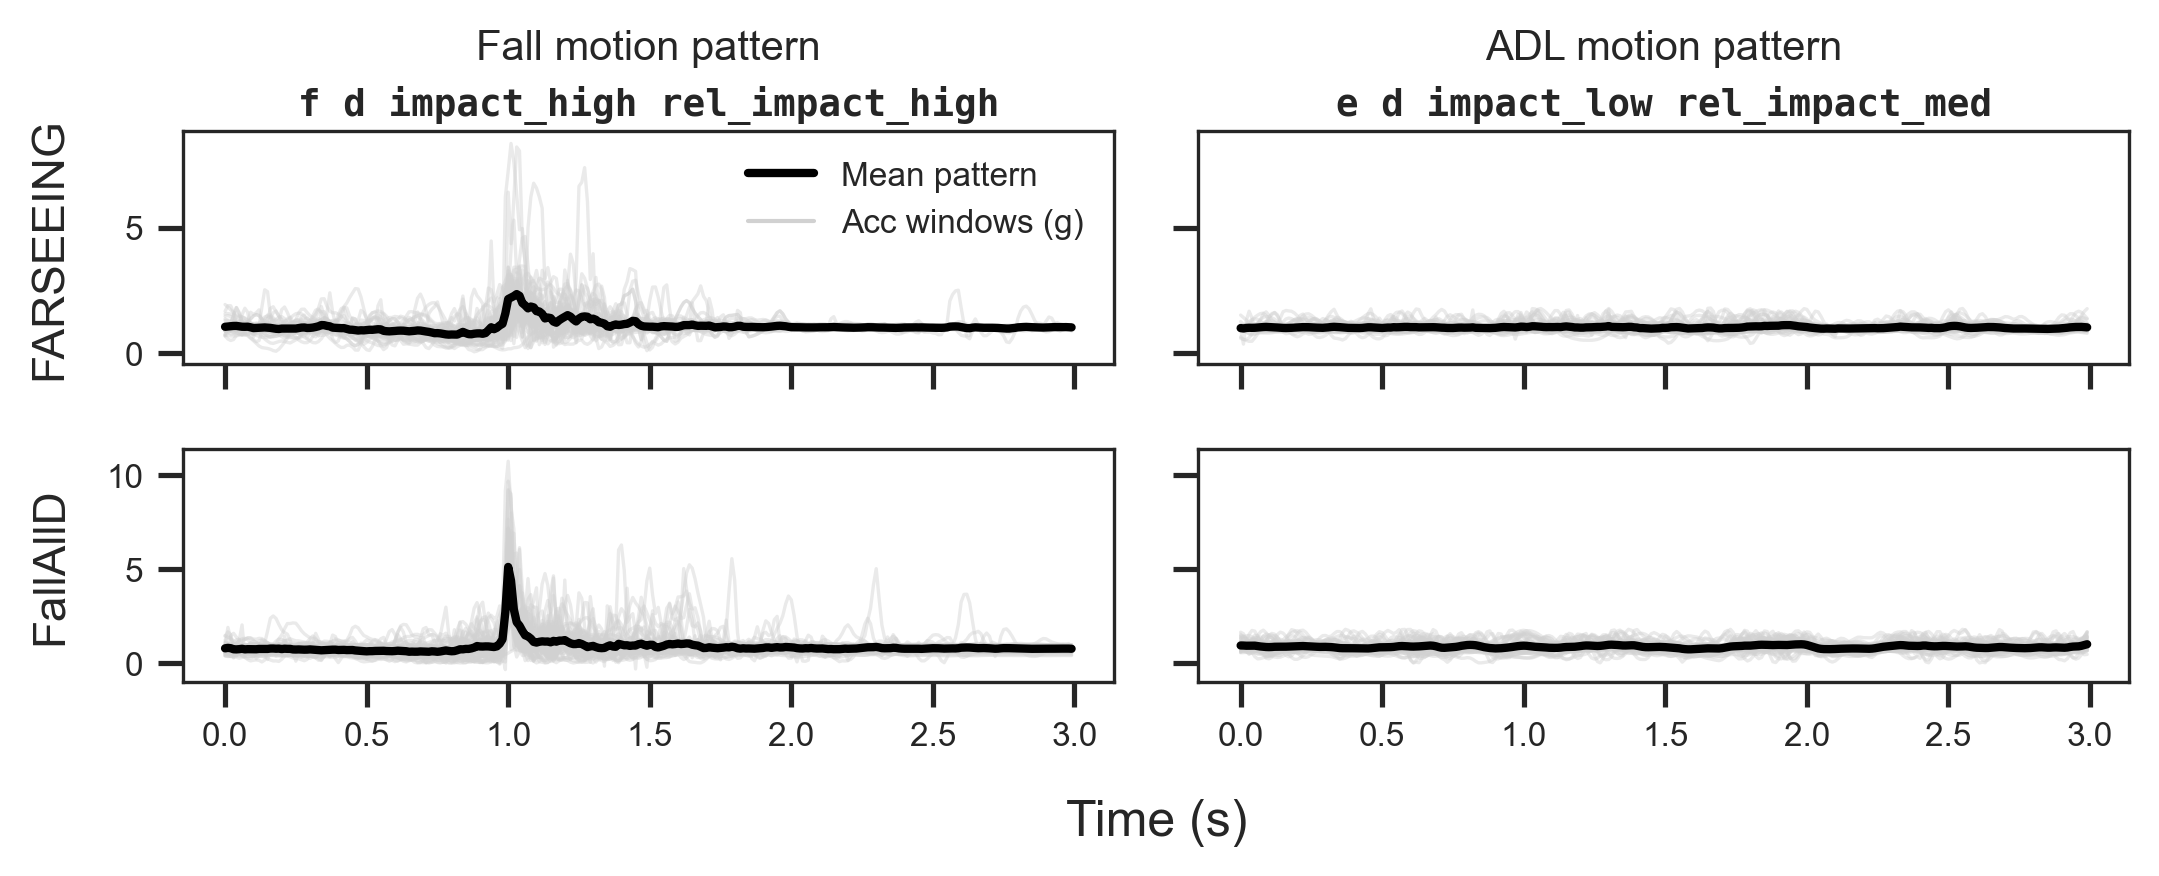

In [24]:
motif_axes = utils.plot_motif_grid(fallLM_farseeing, fallLM_fallalld, motifs_df, 
                    X_train, X_train_f, max_samples=50)
fig = np.ravel(motif_axes)[0].figure
fig.savefig("output/figures/motif_grid.pdf", dpi=300, bbox_inches="tight")